In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Load the dataset
df = pd.read_csv("data.csv")

print("Dataset loaded successfully! ")
print("\nDataset shape:", df.shape)


Dataset loaded successfully! 

Dataset shape: (1143, 15)


In [3]:
print("First 5 rows of the dataset:")
df.head()


First 5 rows of the dataset:


,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
0,708746,17/08/2017,17/08/2017,916,103916,30-34,M,15,17,17,7350.0,1,1.43,2.0,1.0
1,708749,17/08/2017,17/08/2017,916,103917,30-34,M,16,19,21,17861.0,2,1.82,2.0,0.0
2,708771,17/08/2017,17/08/2017,916,103920,30-34,M,20,25,22,693.0,0,0.00,1.0,0.0
3,708815,30/08/2017,30/08/2017,916,103928,30-34,M,28,32,32,4259.0,1,1.25,1.0,0.0
4,708818,17/08/2017,17/08/2017,916,103928,30-34,M,28,33,32,4133.0,1,1.29,1.0,1.0


In [4]:
print("Dataset Information")
print("="*40)

df.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   reporting_start      1143 non-null   object 
 2   reporting_end        1143 non-null   object 
 3   campaign_id          1143 non-null   object 
 4   fb_campaign_id       1143 non-null   object 
 5   age                  1143 non-null   object 
 6   gender               1143 non-null   object 
 7   interest1            1143 non-null   int64  
 8   interest2            1143 non-null   int64  
 9   interest3            1143 non-null   int64  
 10  impressions          1143 non-null   float64
 11  clicks               1143 non-null   int64  
 12  spent                1143 non-null   float64
 13  total_conversion     761 non-null    float64
 14  approved_conversion  761 non-null    float64
dtypes: float64(4), int

In [5]:
# Check missing values first
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
ad_id                    0
reporting_start          0
reporting_end            0
campaign_id              0
fb_campaign_id           0
age                      0
gender                   0
interest1                0
interest2                0
interest3                0
impressions              0
clicks                   0
spent                    0
total_conversion       382
approved_conversion    382
dtype: int64


In [6]:
# Replace missing conversions with 0
df['total_conversion'] = df['total_conversion'].fillna(0)
df['approved_conversion'] = df['approved_conversion'].fillna(0)

print("Missing values fixed! ")


Missing values fixed! 


In [7]:
print(df.isnull().sum())


ad_id                  0
reporting_start        0
reporting_end          0
campaign_id            0
fb_campaign_id         0
age                    0
gender                 0
interest1              0
interest2              0
interest3              0
impressions            0
clicks                 0
spent                  0
total_conversion       0
approved_conversion    0
dtype: int64


In [8]:
# Create CTR column
df['CTR'] = df['clicks'] / df['impressions']

print("CTR column created! ")
df.head()


CTR column created! 


,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion,CTR
0,708746,17/08/2017,17/08/2017,916,103916,30-34,M,15,17,17,7350.0,1,1.43,2.0,1.0,0.000136
1,708749,17/08/2017,17/08/2017,916,103917,30-34,M,16,19,21,17861.0,2,1.82,2.0,0.0,0.000112
2,708771,17/08/2017,17/08/2017,916,103920,30-34,M,20,25,22,693.0,0,0.00,1.0,0.0,0.000000
3,708815,30/08/2017,30/08/2017,916,103928,30-34,M,28,32,32,4259.0,1,1.25,1.0,0.0,0.000235
4,708818,17/08/2017,17/08/2017,916,103928,30-34,M,28,33,32,4133.0,1,1.29,1.0,1.0,0.000242


In [9]:
# Convert to percentage
df['CTR_percent'] = df['CTR'] * 100

df[['impressions','clicks','CTR_percent']].head()


,impressions,clicks,CTR_percent
0,7350.0,1,0.013605
1,17861.0,2,0.011198
2,693.0,0,0.000000
3,4259.0,1,0.023480
4,4133.0,1,0.024195


In [10]:
# Average CTR per campaign
campaign_ctr = df.groupby('campaign_id')['CTR_percent'].mean()

print("Average CTR by Campaign:")
print(campaign_ctr)


Average CTR by Campaign:
campaign_id
1178     0.012854
30-34         inf
35-39    8.099996
40-44    6.244609
45-49    5.122868
916      0.018015
936      0.016502
Name: CTR_percent, dtype: float64


In [11]:
campaign_ctr.sort_values(ascending=False)


campaign_id
30-34         inf
35-39    8.099996
40-44    6.244609
45-49    5.122868
916      0.018015
936      0.016502
1178     0.012854
Name: CTR_percent, dtype: float64

In [12]:
# Convert campaign_id to numeric
df['campaign_id'] = pd.to_numeric(df['campaign_id'], errors='coerce')

# Remove rows where campaign_id is invalid
df = df.dropna(subset=['campaign_id'])

# convert to integer
df['campaign_id'] = df['campaign_id'].astype(int)

print("campaign_id cleaned! ")


campaign_id cleaned! 


In [13]:
campaign_ctr = df.groupby('campaign_id')['CTR_percent'].mean()
campaign_ctr.sort_values(ascending=False)


campaign_id
916     0.018015
936     0.016502
1178    0.012854
Name: CTR_percent, dtype: float64

In [14]:
# create CPC column
df['CPC'] = df['spent'] / df['clicks']

df[['spent','clicks','CPC']].head()


,spent,clicks,CPC
0,1.43,1,1.43
1,1.82,2,0.91
2,0.00,0,NaN
3,1.25,1,1.25
4,1.29,1,1.29


In [15]:
# clean CPC column
df['CPC'] = df['CPC'].replace([float('inf'), -float('inf')], 0)
df['CPC'] = df['CPC'].fillna(0)

print("CPC cleaned! ")


CPC cleaned! 


In [16]:
df[['spent','clicks','CPC']].head(10)


,spent,clicks,CPC
0,1.43,1,1.430000
1,1.82,2,0.910000
2,0.00,0,0.000000
3,1.25,1,1.250000
4,1.29,1,1.290000
5,0.00,0,0.000000
6,4.77,3,1.590000
7,1.27,1,1.270000
8,1.50,1,1.500000
9,3.16,3,1.053333


In [17]:
campaign_cpc = df.groupby('campaign_id')['CPC'].mean()

print("Average CPC by Campaign:")
campaign_cpc.sort_values()


Average CPC by Campaign:


campaign_id
936     0.846742
916     0.862264
1178    1.644663
Name: CPC, dtype: float64

In [18]:
# conversion rate
df['conversion_rate'] = df['approved_conversion'] / df['impressions']

df[['impressions','approved_conversion','conversion_rate']].head()


,impressions,approved_conversion,conversion_rate
0,7350.0,1.0,0.000136
1,17861.0,0.0,0.000000
2,693.0,0.0,0.000000
3,4259.0,0.0,0.000000
4,4133.0,1.0,0.000242


In [19]:
df['conversion_percent'] = df['conversion_rate'] * 100

df[['conversion_percent']].head()


,conversion_percent
0,0.013605
1,0.000000
2,0.000000
3,0.000000
4,0.024195


In [20]:
campaign_conv = df.groupby('campaign_id')['conversion_percent'].mean()

print("Average Conversion Rate by Campaign:")
campaign_conv.sort_values(ascending=False)


Average Conversion Rate by Campaign:


campaign_id
936     0.022755
916     0.013688
1178    0.000781
Name: conversion_percent, dtype: float64

In [21]:
df['CPA'] = df['spent'] / df['approved_conversion']

df[['spent','approved_conversion','CPA']].head()


,spent,approved_conversion,CPA
0,1.43,1.0,1.43
1,1.82,0.0,inf
2,0.00,0.0,NaN
3,1.25,0.0,inf
4,1.29,1.0,1.29


In [22]:
# clean CPA
df['CPA'] = df['CPA'].replace([float('inf'), -float('inf')], 0)
df['CPA'] = df['CPA'].fillna(0)

print("CPA cleaned! ")


CPA cleaned! 


In [23]:
df[['spent','approved_conversion','CPA']].head(10)


,spent,approved_conversion,CPA
0,1.43,1.0,1.43
1,1.82,0.0,0.00
2,0.00,0.0,0.00
3,1.25,0.0,0.00
4,1.29,1.0,1.29
5,0.00,1.0,0.00
6,4.77,0.0,0.00
7,1.27,1.0,1.27
8,1.50,0.0,0.00
9,3.16,0.0,0.00


In [24]:
campaign_cpa = df.groupby('campaign_id')['CPA'].mean()

print("Average CPA by Campaign:")
campaign_cpa.sort_values()


Average CPA by Campaign:


campaign_id
916      1.396296
936      2.037378
1178    28.601278
Name: CPA, dtype: float64

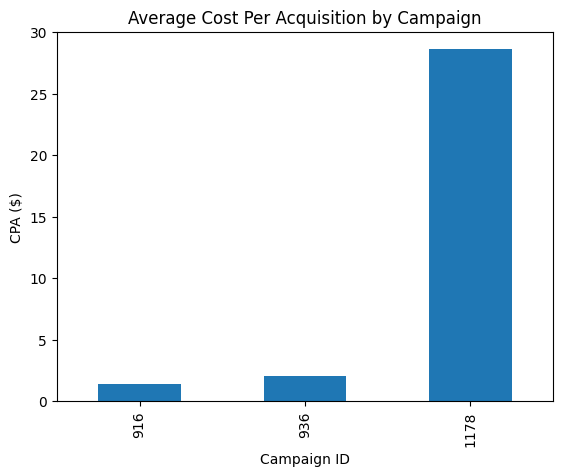

In [25]:
import matplotlib.pyplot as plt

campaign_cpa.plot(kind='bar')
plt.title("Average Cost Per Acquisition by Campaign")
plt.xlabel("Campaign ID")
plt.ylabel("CPA ($)")
plt.show()


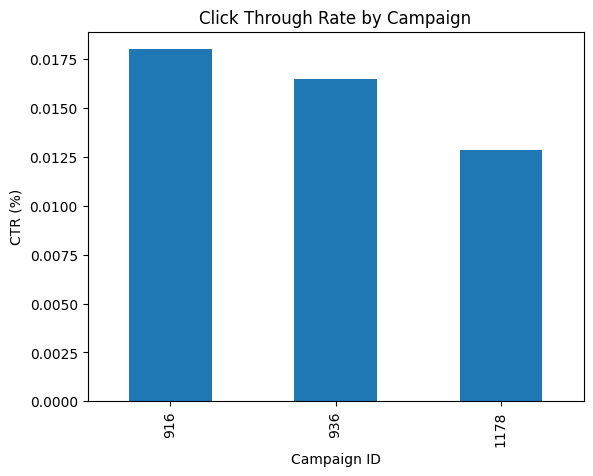

In [26]:
campaign_ctr.plot(kind='bar')
plt.title("Click Through Rate by Campaign")
plt.xlabel("Campaign ID")
plt.ylabel("CTR (%)")
plt.show()


In [27]:
summary = pd.DataFrame({
    'CTR (%)': campaign_ctr,
    'Avg CPC ($)': campaign_cpc,
    'Conversion Rate (%)': campaign_conv,
    'CPA ($)': campaign_cpa
})

summary


,CTR (%),Avg CPC ($),Conversion Rate (%),CPA ($)
campaign_id,,,,
916,0.018015,0.862264,0.013688,1.396296
936,0.016502,0.846742,0.022755,2.037378
1178,0.012854,1.644663,0.000781,28.601278


In [29]:
age_ctr = df.groupby('age')['CTR_percent'].mean()

print("CTR by Age Group:")
age_ctr.sort_values(ascending=False)


CTR by Age Group:


age
45-49    0.022737
40-44    0.019380
35-39    0.015687
30-34    0.011072
Name: CTR_percent, dtype: float64

In [30]:
age_conv = df.groupby('age')['conversion_percent'].mean()

print("Conversion Rate by Age Group:")
age_conv.sort_values(ascending=False)


Conversion Rate by Age Group:


age
30-34    0.019633
40-44    0.016785
45-49    0.012582
35-39    0.007151
Name: conversion_percent, dtype: float64

In [31]:
age_cpa = df.groupby('age')['CPA'].mean()

print("CPA by Age Group:")
age_cpa.sort_values()


CPA by Age Group:


age
30-34     7.149747
45-49     8.278928
35-39    13.698741
40-44    15.935516
Name: CPA, dtype: float64

In [32]:
# assume each conversion worth $50
df['revenue'] = df['approved_conversion'] * 50

df[['approved_conversion','revenue']].head()


,approved_conversion,revenue
0,1.0,50.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,1.0,50.0


In [33]:
df['ROI'] = (df['revenue'] - df['spent']) / df['spent']

df[['spent','revenue','ROI']].head()


,spent,revenue,ROI
0,1.43,50.0,33.965036
1,1.82,0.0,-1.000000
2,0.00,0.0,NaN
3,1.25,0.0,-1.000000
4,1.29,50.0,37.759691


In [34]:
df['ROI'] = df['ROI'].replace([float('inf'), -float('inf')], 0)
df['ROI'] = df['ROI'].fillna(0)


In [35]:
campaign_roi = df.groupby('campaign_id')['ROI'].mean()

print("ROI by Campaign:")
campaign_roi.sort_values(ascending=False)


ROI by Campaign:


campaign_id
916     5.648166
936     5.055975
1178    0.872646
Name: ROI, dtype: float64

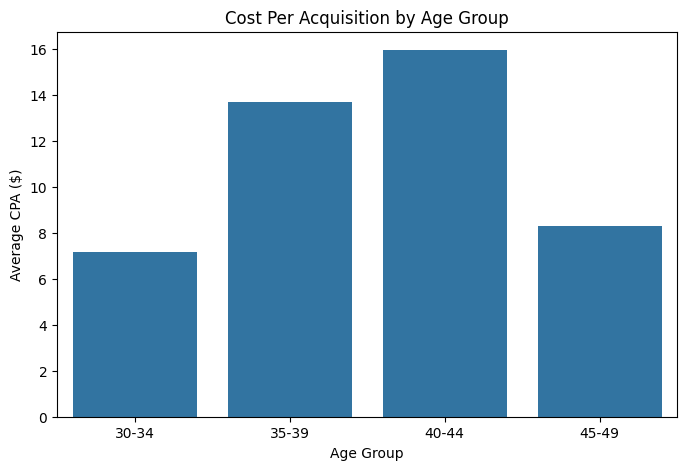

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x=age_cpa.index, y=age_cpa.values)

plt.title("Cost Per Acquisition by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average CPA ($)")

plt.show()


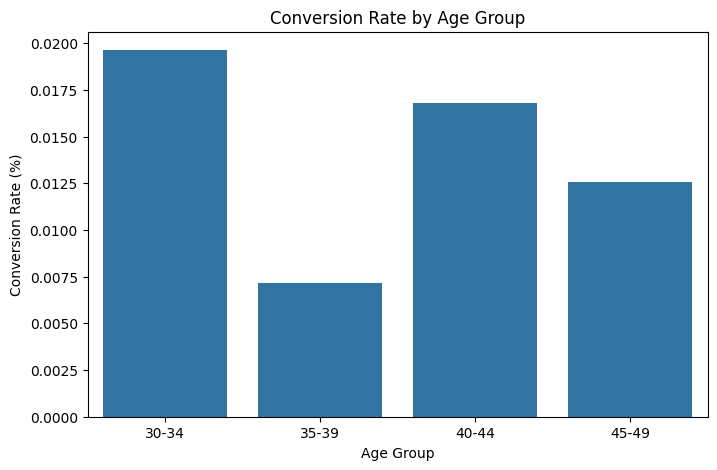

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(x=age_conv.index, y=age_conv.values)

plt.title("Conversion Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate (%)")

plt.show()


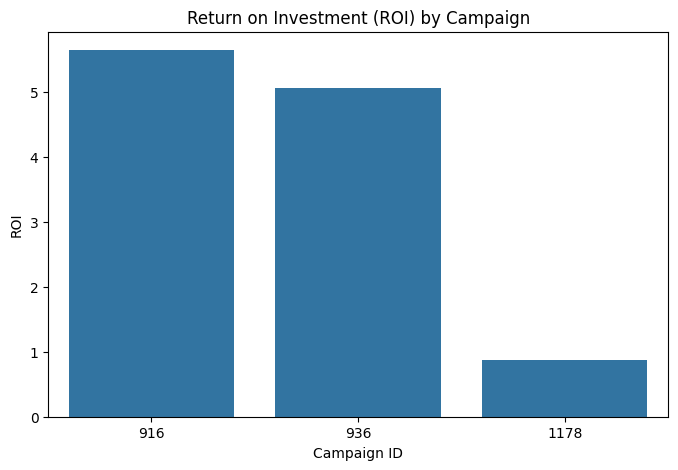

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(x=campaign_roi.index, y=campaign_roi.values)

plt.title("Return on Investment (ROI) by Campaign")
plt.xlabel("Campaign ID")
plt.ylabel("ROI")

plt.show()
